In [1]:
math = [0.04,0.11,0.2,0.12,0.17,0.28,0.38,7.3,72.76,105.46]
bound = [0.03,0.04,0.05,0.05,0.06,0.07,0.14,0.40,0.83,1.51,2.94,6.04]
avg = []

for i in range(len(math)):
    avg.append((math[i] / bound[i]))

print(avg)

average_avg = sum(avg) / len(avg)
print(average_avg)

[1.3333333333333335, 2.75, 4.0, 2.4, 2.8333333333333335, 4.0, 2.714285714285714, 18.25, 87.66265060240966, 69.841059602649]
19.578466258601104


In [2]:
list = [18.25, 87.66265060240966, 69.841059602649]

average_list = sum(list) / len(list)
print(average_list)

58.58457006835289


In [44]:
bound = [0.03,0.04,0.05,0.05,0.06,0.07,0.14,0.40,0.83,1.51,2.94,6.04]

greedy =[0.02,0.05,0.02,0.03,0.03,0.04,0.07,0.08,0.13,0.25,0.44,0.49]

build = [0,0,0.06,14.04,0.02,0,1.31,19.34,1.89,3.01,10.50,20.58]
total = []
for i in range(len(bound)):

    total.append(bound[i] + greedy[i]/60 + build[i]/60)


for i in range(len(total)):
    print (f"{total[i]:.2f} min")

0.03 min
0.04 min
0.05 min
0.28 min
0.06 min
0.07 min
0.16 min
0.72 min
0.86 min
1.56 min
3.12 min
6.39 min


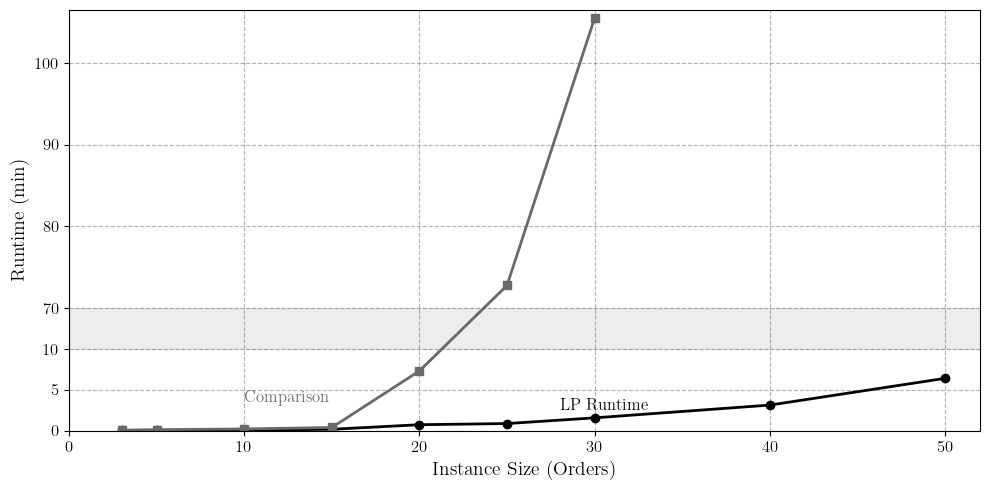

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# LaTeX-Stil aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ----------------------------
# Y-Transformationsfunktion mit Break zwischen 10–70
# ----------------------------
def y_transform(y_vals):
    transformed = []
    for val in y_vals:
        if val <= 10:
            transformed.append(val)
        elif val <= 70:
            # Bereich 10–70 auf 10–15 komprimieren
            transformed.append(10 + (val - 10) * (5 / 60))
        else:
            # Bereich ab 70 normal weiter, versetzt ab 15
            transformed.append(15 + (val - 70))
    return transformed

# ----------------------------
# Daten
# ----------------------------
instances = [3, 5, 10, 15, 20, 25, 30, 40, 50]
lp_runtime = [0.03, 0.04, 0.05, 0.16, 0.72, 0.86, 1.56, 3.12, 6.39]
comp_runtime = [0.04, 0.11, 0.20, 0.38, 7.30, 72.76, 105.46, np.nan, np.nan]

# Transformierte Y-Werte
lp_trans = y_transform(lp_runtime)
comp_trans = y_transform(comp_runtime[:7])

# ----------------------------
# Plot erstellen
# ----------------------------
plt.figure(figsize=(10, 5))
plt.grid(True, which="both", linestyle="--", color="black", alpha=0.3)

# Achsenbeschriftungen
plt.xlabel("Instance Size (Orders)")
plt.ylabel("Runtime (min)")
plt.xlim(0, 52)
plt.ylim(0, max(lp_trans + comp_trans) + 1)

# Angepasste Y-Achsenticks und Labels
plt.yticks(
    [0, 5, 10, 15, 25, 35, 45],
    ["0", "5", "10", "70", "80", "90", "100"]
)

# Schattierter Bereich für Achsensprung
plt.axhspan(10, 15, color="lightgrey", alpha=0.4)

# ----------------------------
# LP Runtime Linie
# ----------------------------
plt.plot(instances, lp_trans, color="black", marker="o", linestyle="-", linewidth=2,
         markersize=6, label="LP Runtime")

# Comparison Runtime Linie (nur bis 30)
plt.plot(instances[:7], comp_trans, color="dimgray", marker="s", linestyle="-", linewidth=2,
         markersize=6, label="Comparison")

# Gestrichelte Verbindung zwischen Break-Punkten (7.30 → 72.76)
x_start = instances[4]  # x-Wert für 7.30
x_end = instances[5]    # x-Wert für 72.76
y_start = comp_trans[4]  # transformiertes 7.30
y_end = comp_trans[5]    # transformiertes 72.76
plt.plot([x_start, x_end], [y_start, y_end],
         linestyle="--", linewidth=1.5, color="dimgray")

# ----------------------------
# Beschriftung
# ----------------------------
plt.text(28, lp_trans[6]+1, "LP Runtime", fontsize=12, color="black")
plt.text(10, comp_trans[3]+3, "Comparison", fontsize=12, color="dimgray")

# ----------------------------
# Speichern und Anzeigen
# ----------------------------
plt.tight_layout()
plt.savefig("runtime_comparison_with_break_10_70.pdf", bbox_inches="tight")
plt.show()

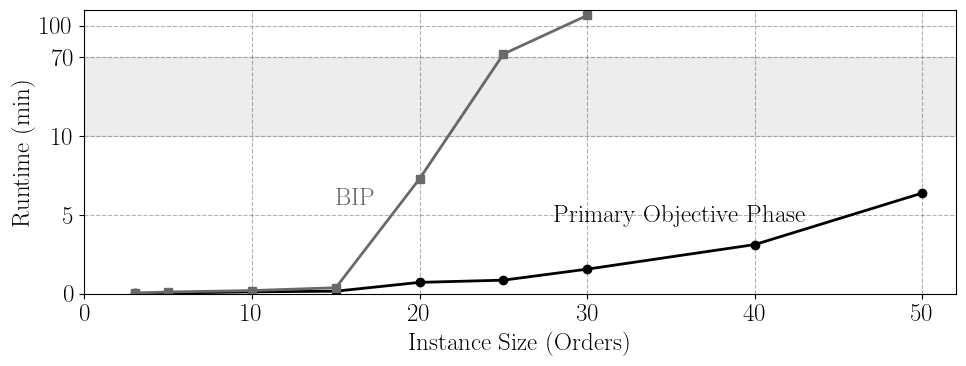

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Stil: wissenschaftlich, LaTeX
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# ----------------------------
# Y-Transformationsfunktion mit 2 Achsensprüngen:
# 10–70 → 10–15, 70–110 → 15–18
# ----------------------------
def y_transform(y_vals):
    transformed = []
    for val in y_vals:
        if val <= 10:
            transformed.append(val)
        elif val <= 70:
            transformed.append(10 + (val - 10) * (5 / 60))  # 10–70 auf 10–15
        else:
            transformed.append(15 + (val - 70) * (3 / 40))  # 70–110 auf 15–18
    return transformed

# ----------------------------
# Daten
# ----------------------------
instances = [3, 5, 10, 15, 20, 25, 30, 40, 50]
lp_runtime = [0.03, 0.04, 0.12, 0.16, 0.72, 0.86, 1.56, 3.12, 6.39]
comp_runtime = [0.04, 0.11, 0.20, 0.38, 7.30, 72.76, 105.46, np.nan, np.nan]


# Transformierte Y-Werte
lp_trans = y_transform(lp_runtime)
comp_trans = y_transform(comp_runtime[:7])

# ----------------------------
# Plot erstellen
# ----------------------------
plt.figure(figsize=(10, 4))
plt.grid(True, which="both", linestyle="--", color="black", alpha=0.3)

# Achsenbeschriftung
plt.xlabel("Instance Size (Orders)")
plt.ylabel("Runtime (min)")
plt.xlim(0, 52)
plt.ylim(0, 18)  # passt zu transformiertem Bereich

# Angepasste Y-Achsenticks & Labels
plt.yticks(
    [0, 5, 10, 15,  17],
    ["0", "5", "10", "70", "100"]
)

# Achsensprünge markieren
plt.axhspan(10, 15, color="lightgrey", alpha=0.4, label="Break: 10–70")
#plt.axhspan(15, 18, color="lightgrey", alpha=0.3, label="Break: 70–110")

# ----------------------------
# LP Runtime Linie
# ----------------------------
plt.plot(instances, lp_trans, color="black", marker="o", linestyle="-", linewidth=2,
         markersize=6, label="LP Runtime")

# Comparison Runtime Linie (nur bis 30)
plt.plot(instances[:7], comp_trans, color="dimgray", marker="s", linestyle="-", linewidth=2,
         markersize=6, label="Comparison")

# Gestrichelte Verbindung zwischen Break-Punkten (7.30 → 72.76)
x_start = instances[4]  # bei 7.30
x_end = instances[5]    # bei 72.76
y_start = comp_trans[4]
y_end = comp_trans[5]
plt.plot([x_start, x_end], [y_start, y_end],
         linestyle="--", linewidth=1.5, color="dimgray")

# ----------------------------
# Beschriftungen im Plot
# ----------------------------
plt.text(28, lp_trans[6]+3.0, "Primary Objective Phase", fontsize=18, color="black")
plt.text(15, comp_trans[4]-1.7, "BIP", fontsize=18, color="dimgray")

# ----------------------------
# Speichern & Anzeigen
# ----------------------------
plt.tight_layout()
plt.savefig("runtime_comparison_bip_primary_phase.pdf", bbox_inches="tight")
plt.show()